In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os, glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NC_9 = Rv0010c-Rv0011c

NC_2516 = whiB2-fbiA

NC_2568 = dacB1-sugI

NC_2982 = whiB6-Rv3863

In [10]:
# order in decreasing significance
genes_lst = ['sugI', 'devR', 'phoR', 'Rv2690c', 'Rv1830', 'whiB6', 'devS',
               'virS', 'whiB2-fbiA', 'subI', 'Rv1733c', 'Rv3220c', 'ceoB', 'mtrA',
               'Rv3861', 'katG'
            ]

rename_genes = {'NC_9': 'Rv0010c-Rv0011c',
                'NC_2516': 'whiB2-fbiA',
                'NC_2568': 'dacB1-sugI',
                'NC_2982': 'whiB6-Rv3863'
               }

print(len(genes_lst))

16


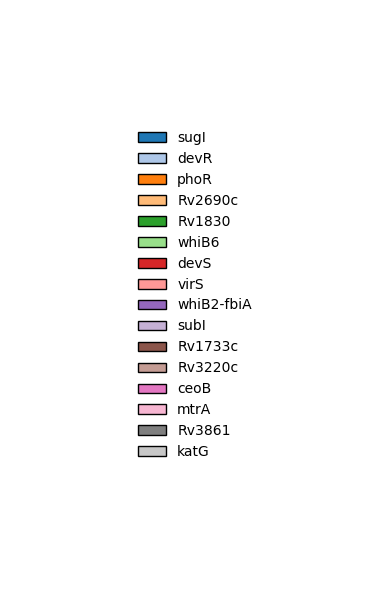

In [23]:
colors = dict(zip(genes_lst, sns.color_palette('tab20').as_hex()[:len(genes_lst)]))
# print(len(colors))

# Create legend handles
handles = [Patch(facecolor=color, edgecolor='black', label=label)
           for label, color in colors.items()]

fig, ax = plt.subplots(figsize=(4, 6))
ax.legend(handles=handles, loc='center', frameon=False)
ax.axis('off')

plt.tight_layout()
plt.savefig("regions_legend.svg", bbox_inches='tight')

In [6]:
template_string = """DATASET_COLORSTRIP
#In colored strip datasets, each ID is associated to a color box/strip and can have an optional label. Color can be specified in hexadecimal, RGB or RGBA notation. When using RGB or RGBA notation, you cannot use COMMA as the dataset separator

#lines starting with a hash are comments and ignored during parsing

#=================================================================#
#                    MANDATORY SETTINGS                           #
#=================================================================#
#select the separator which is used to delimit the data below (TAB,SPACE or COMMA).This separator must be used throughout this file.

SEPARATOR TAB
#SEPARATOR COMMA
#SEPARATOR SPACE

#label is used in the legend table (can be changed later)
DATASET_LABEL	NAME_TO_REPLACE

#dataset color (can be changed later)
COLOR	#ff0000

#=================================================================#
#                    OPTIONAL SETTINGS                            #
#=================================================================#

#If COLOR_BRANCHES is set to 1, branches of the tree will be colored according to the colors of the strips above the leaves.
#When all children of a node have the same color, it will be colored the same, ie. the color will propagate inwards towards the root.
COLOR_BRANCHES	0


#=================================================================#
#     all other optional settings can be set or changed later     #
#           in the web interface (under 'Datasets' tab)           #
#=================================================================#

#Each dataset can have a legend, which is defined using LEGEND_XXX fields below
#For each row in the legend, there should be one shape, color and label.
#Optionally, you can define an exact legend position using LEGEND_POSITION_X and LEGEND_POSITION_Y. To use automatic legend positioning, do NOT define these values
#Optionally, shape scaling can be present (LEGEND_SHAPE_SCALES). For each shape, you can define a scaling factor between 0 and 1.
#To order legend entries horizontally instead of vertically, set LEGEND_HORIZONTAL to 1
#Shape should be a number between 1 and 12, or any protein domain shape definition.
#1: square
#2: circle
#3: star
#4: right pointing triangle
#5: left pointing triangle
#6: checkmark
#7: solid line
#8: dashed line
#9: dotted line
#10:arrow left
#11:arrow right
#12:bidirectional arrow

LEGEND_TITLE	NAME_TO_REPLACE
#LEGEND_SCALE 	1
LEGEND_POSITION_X	100
LEGEND_POSITION_Y	100
LEGEND_HORIZONTAL	0
LEGEND_SHAPES	1	1
LEGEND_COLORS	#ffffff	COLOR_TO_REPLACE
LEGEND_LABELS	0	1
LEGEND_SHAPE_SCALES	1	1

#width of the colored strip
#STRIP_WIDTH 25

#left margin, used to increase/decrease the spacing to the next dataset. Can be negative, causing datasets to overlap.
#MARGIN 0

#border width; if set above 0, a border of specified width (in pixels) will be drawn around the color strip 
BORDER_WIDTH	1

#border color; used when BORDER_WIDTH is above 0
BORDER_COLOR	#000000

#if set to 1, border will be drawn completely around each colored strip box
COMPLETE_BORDER	1

#always show internal values; if set, values associated to internal nodes will be displayed even if these nodes are not collapsed. It could cause overlapping in the dataset display.
#SHOW_INTERNAL 0


#display or hide the individual label inside each colored strip (when defined in the data below)
#SHOW_STRIP_LABELS 1

#position of the strip label within the box; 'top', 'center' or 'bottom'
#STRIP_LABEL_POSITION center

#strip label size factor (relative to the tree leaf labels)
#STRIP_LABEL_SIZE_FACTOR 1


#rotation of the strip labels; used only in rectangular tree display mode
#STRIP_LABEL_ROTATION 0

#strip label shift in pixels (positive or negative)
#STRIP_LABEL_SHIFT 0

#STRIP_LABEL_COLOR #000000

#draw a black outline around the text (width in pixels)
#STRIP_LABEL_OUTLINE 0.5

#calculate the label color automatically (black or white), based on the darkness of the color strip
#STRIP_LABEL_AUTO_COLOR 0

#display or hide the dataset label above the colored strip
#SHOW_LABELS 1

#dataset label size factor
#SIZE_FACTOR 1

#dataset label rotation
#LABEL_ROTATION 0

#dataset label shift in pixels (positive or negative)
#LABEL_SHIFT 0

#align the dataset label to the tree circle; only applies in circular display mode
#LABEL_ALIGN_TO_TREE,0

#Internal tree nodes can be specified using IDs directly, or using the 'last common ancestor' method described in iTOL help pages

#=================================================================#
#       Actual data follows after the "DATA" keyword              #
#=================================================================#
DATA

#Examples:
#assign a red colored strip to leaf 9606, with label 'Human'
#9606 #ff0000 Human

#assign a green, semi-transparent (alpha 0.5) strip to an internal node, without any label. If 'Show internal values' is set to 'No', this will only be displayed if the node is collapsed. 
#9606|5664 rgba(0,255,0,0.5)
"""

In [21]:
df = pd.read_csv("16_enriched_baseline_regions.csv")

for col in rename_genes.keys():
    df.rename(columns={col: rename_genes[col]}, inplace=True)
    
df = df[['SampleID'] + genes_lst]

for i, col in enumerate(df.columns[1:]):

    df[col] = df[col].map({0: '#ffffff', 1: colors[col]})

    # df.iloc[:, [0, i+1]].to_csv(f"{col}_baseline_sample_presence_color_strip.txt", sep='\t', index=False)

    with open(f"customizations/{col}_baseline_sample_presence_color_strip.txt", "w+") as file:
    
        # rename the dataset name so that it appears in the legend
        file.write(template_string.replace('NAME_TO_REPLACE', col).replace('COLOR_TO_REPLACE', colors[col]) + "\n")
    
        for _, row in df.iloc[:, [0, i+1]].iterrows():
    
            file.write(row.to_string(index=False, header=False).replace('\n', '\t') + '\n')